# Analiza geograficzna

In [9]:
import pandas as pd

data = pd.read_csv("clean_spotify_data.csv")

In [10]:
import pandas as pd
import country_converter as coco
import matplotlib.pyplot as plt
import seaborn as sns

# kopia danych
geo_data = data.copy()

# sprawdzenie unikalnych regionów
regions = sorted(geo_data["region"].dropna().unique())
print(regions[:20])
print("Liczba regionów:", len(regions))

['Andorra', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Finland']
Liczba regionów: 70


In [11]:
import pandas as pd
import country_converter as coco

geo_data = geo_data.copy()

region_fixes = {
    "Czech Republic": "Czechia",
    "South Korea": "Korea, Republic of",
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "Moldova": "Moldova, Republic of",
    "Global": pd.NA
}

geo_data["region_fixed"] = geo_data["region"].replace(region_fixes)

In [16]:
macroregion_map = {
    # Northern / Western / Southern / Eastern Europe
    "United Kingdom": "Northern Europe",
    "Ireland": "Northern Europe",
    "Sweden": "Northern Europe",
    "Norway": "Northern Europe",
    "Finland": "Northern Europe",
    "Denmark": "Northern Europe",
    "Iceland": "Northern Europe",

    "Germany": "Western Europe",
    "France": "Western Europe",
    "Belgium": "Western Europe",
    "Netherlands": "Western Europe",
    "Luxembourg": "Western Europe",
    "Austria": "Western Europe",
    "Switzerland": "Western Europe",

    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Italy": "Southern Europe",
    "Greece": "Southern Europe",

    "Poland": "Eastern/Central Europe",
    "Czechia": "Eastern/Central Europe",
    "Slovakia": "Eastern/Central Europe",
    "Hungary": "Eastern/Central Europe",
    "Romania": "Eastern/Central Europe",
    "Bulgaria": "Eastern/Central Europe",
    "Croatia": "Eastern/Central Europe",
    "Serbia": "Eastern/Central Europe",
    "Ukraine": "Eastern/Central Europe",
    "Lithuania": "Eastern/Central Europe",
    "Latvia": "Eastern/Central Europe",
    "Estonia": "Eastern/Central Europe",

    # Americas
    "United States": "North America",
    "Canada": "North America",

    "Mexico": "Latin America",
    "Brazil": "Latin America",
    "Argentina": "Latin America",
    "Chile": "Latin America",
    "Colombia": "Latin America",
    "Peru": "Latin America",
    "Uruguay": "Latin America",
    "Paraguay": "Latin America",
    "Bolivia": "Latin America",
    "Ecuador": "Latin America",
    "Costa Rica": "Latin America",
    "Guatemala": "Latin America",
    "Panama": "Latin America",
    "Honduras": "Latin America",
    "Nicaragua": "Latin America",
    "El Salvador": "Latin America",
    "Dominican Republic": "Latin America",

    # Asia
    "Japan": "East Asia",
    "South Korea": "East Asia",
    "Taiwan": "East Asia",
    "Hong Kong": "East Asia",

    "India": "South/Southeast Asia",
    "Indonesia": "South/Southeast Asia",
    "Thailand": "South/Southeast Asia",
    "Philippines": "South/Southeast Asia",
    "Malaysia": "South/Southeast Asia",
    "Singapore": "South/Southeast Asia",
    "Vietnam": "South/Southeast Asia",

    # Middle East
    "Saudi Arabia": "Middle East",
    "United Arab Emirates": "Middle East",
    "Israel": "Middle East",
    "Egypt": "Middle East",
    "Morocco": "Middle East",

    # Africa
    "South Africa": "Africa",

    # Oceania
    "Australia": "Oceania",
    "New Zealand": "Oceania"
}

In [ ]:
geo_data["macroregion"] = geo_data["region_fixed"].map(macroregion_map)

In [ ]:
geo_data[["region", "region_fixed", "macroregion"]].drop_duplicates().sort_values("region")

,region,region_fixed,macroregion
23399,Andorra,Andorra,NaN
0,Argentina,Argentina,Latin America
58,Australia,Australia,Oceania
170,Austria,Austria,Western Europe
232,Belgium,Belgium,Western Europe
...,...,...,...
108369,United Arab Emirates,United Arab Emirates,Middle East
3586,United Kingdom,United Kingdom,Northern Europe
3691,United States,United States,North America
3795,Uruguay,Uruguay,Latin America


In [19]:
missing_macro = geo_data.loc[geo_data["macroregion"].isna(), "region_fixed"].dropna().unique()
print(sorted(missing_macro))
print("Liczba brakujących krajów:", len(missing_macro))

['Andorra', 'Korea, Republic of', 'Russian Federation', 'Turkey', 'Viet Nam']
Liczba brakujących krajów: 5


In [20]:
macroregion_map.update({
    "Andorra": "Southern Europe",
    "Korea, Republic of": "East Asia",
    "Russian Federation": "Eastern/Central Europe",
    "Turkey": "Middle East",
    "Viet Nam": "South/Southeast Asia"
})

In [21]:
geo_data["macroregion"] = geo_data["region_fixed"].map(macroregion_map)

In [22]:
missing_macro = geo_data.loc[geo_data["macroregion"].isna(), "region_fixed"].dropna().unique()
print(sorted(missing_macro))
print("Liczba brakujących krajów:", len(missing_macro))

[]
Liczba brakujących krajów: 0


## Podstawowy opis makroregionów

In [23]:
region_summary = (
    geo_data.groupby("macroregion")
    .agg(
        records=("macroregion", "size"),
        countries=("region_fixed", "nunique"),
        tracks=("track_id", "nunique"),
        artists=("track_artist", "nunique")
    )
    .sort_values("records", ascending=False)
)

region_summary

,records,countries,tracks,artists
macroregion,,,,
Latin America,2939900,17,3414,1455
Eastern/Central Europe,989675,11,2951,1282
Northern Europe,918979,7,3156,1390
Western Europe,801839,7,3001,1410
South/Southeast Asia,759944,7,1907,851
Southern Europe,557804,5,3225,1347
Oceania,402570,2,1872,842
North America,370970,2,2154,845
Middle East,341024,6,1700,776


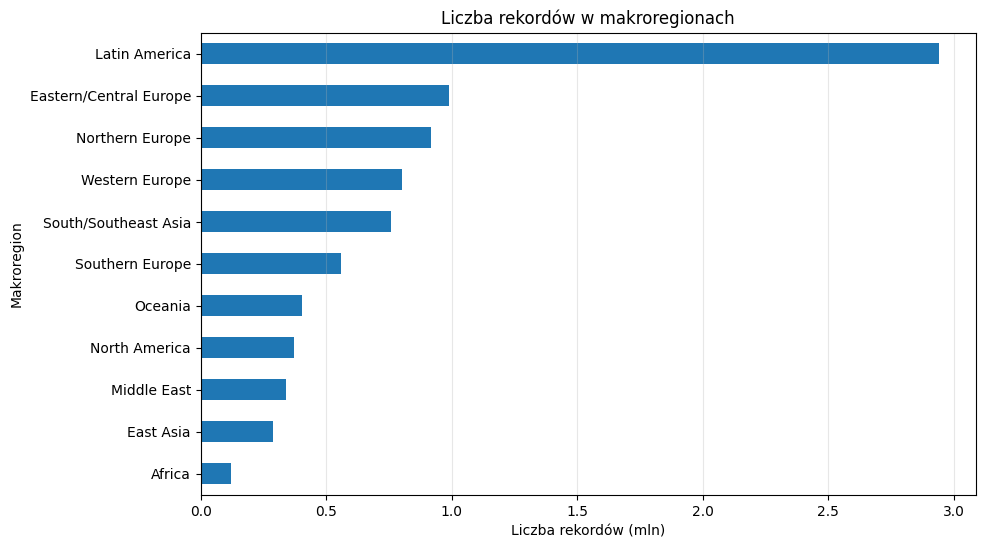

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))
region_summary["records"].sort_values().plot(kind="barh")

plt.title("Liczba rekordów w makroregionach")
plt.xlabel("Liczba rekordów (mln)")
plt.ylabel("Makroregion")
plt.grid(True, axis="x", alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}"))

plt.show()

## Czy w tych samych miesiącach w różnych krajach popularne były te same utwory?

In [35]:
top10_monthly = geo_data[geo_data["rank"] <= 10].copy()

top10_monthly["date"] = pd.to_datetime(top10_monthly["date"])
top10_monthly["month"] = top10_monthly["date"].dt.to_period("M").astype(str)

top10_monthly.head()

,title,rank,date,artist,url,region,chart,trend,track_id,track_name,...,instrumentalness,liveness,valence,tempo,duration_ms,region_fixed,continent,macroregion,month,year
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,6mICuAdrwEjh6Y6lroV2Kg,Chantaje (feat. Maluma),...,0.000030,0.159,0.907,102.034,195840.0,Argentina,America,Latin America,2017-01,2017
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,7DM4BPaS7uofFul3ywMe46,Vente Pa' Ca,...,0.000017,0.101,0.533,99.935,259196.0,Argentina,America,Latin America,2017-01,2017
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,3AEZUABDXNtecAOSC1qTfo,Reggaetón Lento (Bailemos),...,0.000000,0.176,0.710,93.974,222560.0,Argentina,America,Latin America,2017-01,2017
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,6rQSrBHf7HlZjtcMZ4S4bO,Safari,...,0.000003,0.126,0.555,180.044,205600.0,Argentina,America,Latin America,2017-01,2017
4,Traicionera,6,2017-01-01,Sebastian Yatra,https://open.spotify.com/track/5J1c3M4EldCfNxX...,Argentina,top200,MOVE_DOWN,5J1c3M4EldCfNxXwrwt8mT,Traicionera,...,0.000000,0.219,0.661,91.012,228467.0,Argentina,America,Latin America,2017-01,2017


In [36]:
top10_monthly["track_label"] = (
    top10_monthly["track_name"].astype(str) + " — " + top10_monthly["track_artist"].astype(str)
)

In [37]:
monthly_sets = (
    top10_monthly.groupby(["month", "macroregion"])["track_label"]
    .apply(set)
    .reset_index()
)

monthly_sets.head()

,month,macroregion,track_label
0,2017-01,East Asia,"{Lady (feat. Pitbull) — Austin Mahone, How Far..."
1,2017-01,Eastern/Central Europe,{Bad Things - With Camila Cabello — Machine Gu...
2,2017-01,Latin America,"{Al Filo de Tu Amor — Carlos Vives, Lady (feat..."
3,2017-01,Middle East,"{Shape of You — Ed Sheeran, I Don’t Wanna Live..."
4,2017-01,North America,"{Electric (feat. Khalid) — Alina Baraz, Fake L..."


In [38]:
def jaccard_similarity(set1, set2):
    if not set1 and not set2:
        return None
    return len(set1 & set2) / len(set1 | set2)

In [39]:
from itertools import combinations
import pandas as pd

regions = sorted(top10_monthly["macroregion"].dropna().unique())

results = []

for region1, region2 in combinations(regions, 2):
    sim_values = []
    
    for month in sorted(monthly_sets["month"].unique()):
        set1_row = monthly_sets[(monthly_sets["month"] == month) & (monthly_sets["macroregion"] == region1)]
        set2_row = monthly_sets[(monthly_sets["month"] == month) & (monthly_sets["macroregion"] == region2)]
        
        set1 = set1_row["track_label"].iloc[0] if not set1_row.empty else set()
        set2 = set2_row["track_label"].iloc[0] if not set2_row.empty else set()
        
        sim = jaccard_similarity(set1, set2)
        if sim is not None:
            sim_values.append(sim)
    
    avg_sim = sum(sim_values) / len(sim_values) if sim_values else None
    
    results.append({
        "region1": region1,
        "region2": region2,
        "avg_jaccard": avg_sim
    })

jaccard_df = pd.DataFrame(results)
jaccard_df.sort_values("avg_jaccard", ascending=False).head(20)

,region1,region2,avg_jaccard
41,North America,Oceania,0.442398
22,Eastern/Central Europe,Northern Europe,0.434712
48,Northern Europe,Western Europe,0.421210
26,Eastern/Central Europe,Western Europe,0.418357
40,North America,Northern Europe,0.411489
45,Northern Europe,Oceania,0.382647
16,East Asia,South/Southeast Asia,0.379641
21,Eastern/Central Europe,North America,0.369653
44,North America,Western Europe,0.356708
51,Oceania,Western Europe,0.355350


In [40]:
matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)

for region in regions:
    matrix.loc[region, region] = 1.0

for _, row in jaccard_df.iterrows():
    matrix.loc[row["region1"], row["region2"]] = row["avg_jaccard"]
    matrix.loc[row["region2"], row["region1"]] = row["avg_jaccard"]

matrix

,Africa,East Asia,Eastern/Central Europe,Latin America,Middle East,North America,Northern Europe,Oceania,South/Southeast Asia,Southern Europe,Western Europe
Africa,1.000000,0.230534,0.215267,0.096884,0.242531,0.298468,0.214349,0.302076,0.193665,0.148236,0.225329
East Asia,0.230534,1.000000,0.285164,0.137652,0.253561,0.293501,0.300232,0.310913,0.379641,0.199321,0.253838
Eastern/Central Europe,0.215267,0.285164,1.000000,0.195310,0.327801,0.369653,0.434712,0.329365,0.286601,0.351518,0.418357
Latin America,0.096884,0.137652,0.195310,1.000000,0.162119,0.187733,0.188673,0.156776,0.162970,0.259572,0.204505
Middle East,0.242531,0.253561,0.327801,0.162119,1.000000,0.291345,0.296750,0.302930,0.277258,0.251324,0.328039
North America,0.298468,0.293501,0.369653,0.187733,0.291345,1.000000,0.411489,0.442398,0.257854,0.256023,0.356708
Northern Europe,0.214349,0.300232,0.434712,0.188673,0.296750,0.411489,1.000000,0.382647,0.293235,0.286624,0.421210
Oceania,0.302076,0.310913,0.329365,0.156776,0.302930,0.442398,0.382647,1.000000,0.296193,0.234126,0.355350
South/Southeast Asia,0.193665,0.379641,0.286601,0.162970,0.277258,0.257854,0.293235,0.296193,1.000000,0.223159,0.302251
Southern Europe,0.148236,0.199321,0.351518,0.259572,0.251324,0.256023,0.286624,0.234126,0.223159,1.000000,0.306504


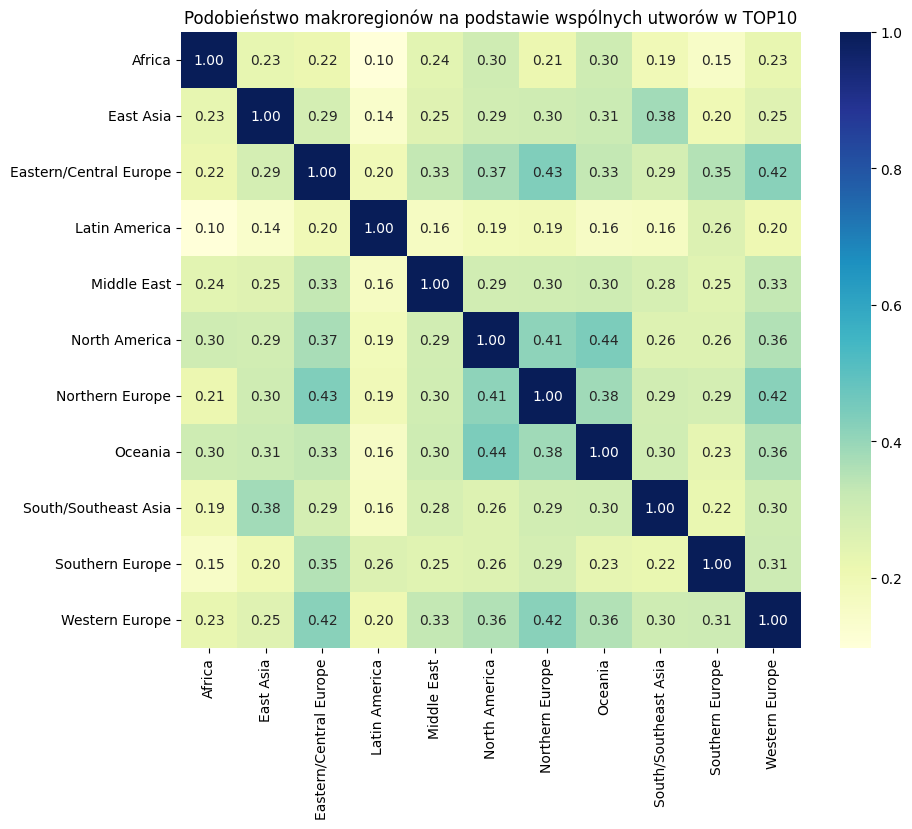

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Podobieństwo makroregionów na podstawie wspólnych utworów w TOP10")
plt.show()

## Podobieństwo makroregionów na podstawie wspólnych artystów

In [47]:
top20_artist_time = geo_data[geo_data["rank"] <= 20].copy()
top20_artist_time["date"] = pd.to_datetime(top20_artist_time["date"])
top20_artist_time["year"] = top20_artist_time["date"].dt.year

In [48]:
artist_counts = (
    top20_artist_time.groupby(["year", "macroregion", "track_artist"])
    .size()
    .reset_index(name="count")
)

artist_counts.head()

,year,macroregion,track_artist,count
0,2017,East Asia,21 Savage,9
1,2017,East Asia,A$AP Ferg,5
2,2017,East Asia,AREA21,14
3,2017,East Asia,Aerosmith,5
4,2017,East Asia,Afrojack,3


In [51]:
artist_counts = (
    top20_artist_time.groupby(["year", "macroregion", "track_artist"])
    .size()
    .reset_index(name="count")
)

In [52]:
top1_artist_by_region_year = (
    artist_counts.sort_values(
        ["year", "macroregion", "count"],
        ascending=[True, True, False]
    )
    .groupby(["year", "macroregion"])
    .head(1)
)

top1_artist_by_region_year

,year,macroregion,track_artist,count
62,2017,East Asia,Ed Sheeran,1804
307,2017,Eastern/Central Europe,Ed Sheeran,3605
742,2017,Latin America,J Balvin,8034
1068,2017,Middle East,Ed Sheeran,399
1197,2017,North America,Kendrick Lamar,805
1363,2017,Northern Europe,Ed Sheeran,2897
1623,2017,Oceania,Ed Sheeran,946
1796,2017,South/Southeast Asia,Ed Sheeran,2451
2007,2017,Southern Europe,Ed Sheeran,1656
2349,2017,Western Europe,Ed Sheeran,3120


In [53]:
top1_artist_selected = top1_artist_by_region_year[
    top1_artist_by_region_year["year"].isin([2018, 2019, 2020, 2021])
].copy()

top1_artist_selected

,year,macroregion,track_artist,count
2707,2018,Africa,Post Malone,357
2867,2018,East Asia,Marshmello,651
3139,2018,Eastern/Central Europe,Post Malone,2673
3412,2018,Latin America,Ozuna,11087
3540,2018,Middle East,Drake,673
3712,2018,North America,Drake,1242
3930,2018,Northern Europe,Drake,2438
4148,2018,Oceania,Drake,957
4399,2018,South/Southeast Asia,Marshmello,1679
4569,2018,Southern Europe,Drake,1528


In [54]:
top1_artist_table = top1_artist_selected.pivot(
    index="macroregion",
    columns="year",
    values="track_artist"
)

top1_artist_table

year,2018,2019,2020,2021
macroregion,,,,
Africa,Post Malone,Post Malone,Roddy Ricch,Lewis Capaldi
East Asia,Marshmello,Ed Sheeran,Shawn Mendes,Daft Punk
Eastern/Central Europe,Post Malone,Billie Eilish,SAINt JHN,Elley Duhé
Latin America,Ozuna,Anuel AA,Dalex,Younha
Middle East,Drake,Billie Eilish,Roddy Ricch,Elley Duhé
North America,Drake,Post Malone,Roddy Ricch,Mariah Carey
Northern Europe,Drake,Post Malone,SAINt JHN,Elley Duhé
Oceania,Drake,Post Malone,Harry Styles,Fleetwood Mac
South/Southeast Asia,Marshmello,Post Malone,Lewis Capaldi,Lewis Capaldi


## Cechy muzyczne popularnych utworów między makroregionami

In [56]:
top20_features = geo_data[geo_data["rank"] <= 20].copy()

In [57]:
feature_cols = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "tempo"
]

region_features = (
    top20_features.groupby("macroregion")[feature_cols]
    .mean()
)

region_features

,danceability,energy,valence,acousticness,speechiness,tempo
macroregion,,,,,,
Africa,0.711209,0.608522,0.476710,0.253327,0.125179,116.733758
East Asia,0.685080,0.635660,0.510871,0.234990,0.091469,115.278945
Eastern/Central Europe,0.706037,0.634204,0.491918,0.212691,0.112699,118.697057
Latin America,0.746183,0.710984,0.626717,0.229933,0.122553,120.303371
Middle East,0.719312,0.606012,0.500456,0.238899,0.114096,119.590600
North America,0.731018,0.608290,0.485199,0.209348,0.133988,119.285109
Northern Europe,0.698528,0.639373,0.496346,0.222825,0.108772,117.577942
Oceania,0.707889,0.624680,0.498478,0.228053,0.112491,116.871171
South/Southeast Asia,0.680846,0.614686,0.499153,0.265706,0.087977,115.442329


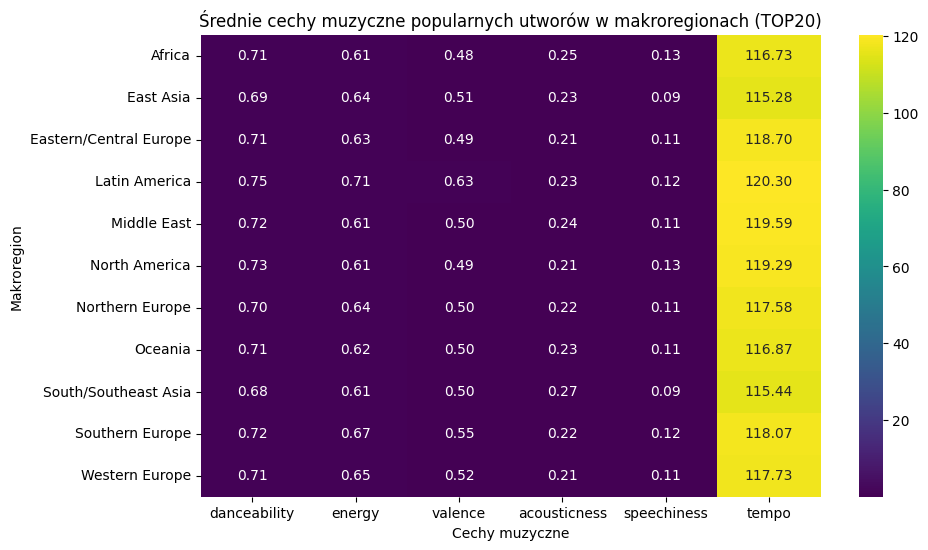

In [58]:
plt.figure(figsize=(10, 6))
sns.heatmap(region_features, annot=True, cmap="viridis", fmt=".2f")
plt.title("Średnie cechy muzyczne popularnych utworów w makroregionach (TOP20)")
plt.xlabel("Cechy muzyczne")
plt.ylabel("Makroregion")
plt.show()

## Jak rozprzestrzeniała się popularność wykonawców między regionami?

In [60]:
artist_spread = geo_data[geo_data["rank"] <= 10].copy()
artist_spread["date"] = pd.to_datetime(artist_spread["date"])

In [61]:
selected_artists = ["Drake", "Post Malone", "Billie Eilish", "SAINt JHN"]

In [62]:
first_artist_hit = (
    artist_spread[artist_spread["track_artist"].isin(selected_artists)]
    .groupby(["track_artist", "macroregion"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "first_top10_date"})
)

first_artist_hit

,track_artist,macroregion,first_top10_date
0,Billie Eilish,Africa,2018-04-25
1,Billie Eilish,East Asia,2018-05-01
2,Billie Eilish,Eastern/Central Europe,2018-04-25
3,Billie Eilish,Latin America,2018-04-23
4,Billie Eilish,Middle East,2018-04-30
5,Billie Eilish,North America,2018-04-23
6,Billie Eilish,Northern Europe,2018-04-30
7,Billie Eilish,Oceania,2018-04-23
8,Billie Eilish,South/Southeast Asia,2018-04-23
9,Billie Eilish,Southern Europe,2018-04-30


In [63]:
artist_spread_table = first_artist_hit.pivot(
    index="macroregion",
    columns="track_artist",
    values="first_top10_date"
)

artist_spread_table

track_artist,Billie Eilish,Drake,Post Malone,SAINt JHN
macroregion,,,,
Africa,2018-04-25,2018-03-14,2018-03-14,2020-03-17
East Asia,2018-05-01,2017-03-21,2017-02-19,2020-03-23
Eastern/Central Europe,2018-04-25,2017-01-01,2017-02-02,2019-10-09
Latin America,2018-04-23,2017-01-01,2017-02-12,2020-03-20
Middle East,2018-04-30,2017-01-01,2017-09-18,2019-12-20
North America,2018-04-23,2017-01-01,2017-02-15,2019-10-16
Northern Europe,2018-04-30,2017-01-01,2017-02-24,2019-10-24
Oceania,2018-04-23,2017-01-01,2017-09-17,2019-12-01
South/Southeast Asia,2018-04-23,2017-06-28,2017-09-18,2020-03-30


In [64]:
first_artist_hit["first_top10_month"] = first_artist_hit["first_top10_date"].dt.to_period("M").astype(str)

artist_spread_month_table = first_artist_hit.pivot(
    index="macroregion",
    columns="track_artist",
    values="first_top10_month"
)

artist_spread_month_table

track_artist,Billie Eilish,Drake,Post Malone,SAINt JHN
macroregion,,,,
Africa,2018-04,2018-03,2018-03,2020-03
East Asia,2018-05,2017-03,2017-02,2020-03
Eastern/Central Europe,2018-04,2017-01,2017-02,2019-10
Latin America,2018-04,2017-01,2017-02,2020-03
Middle East,2018-04,2017-01,2017-09,2019-12
North America,2018-04,2017-01,2017-02,2019-10
Northern Europe,2018-04,2017-01,2017-02,2019-10
Oceania,2018-04,2017-01,2017-09,2019-12
South/Southeast Asia,2018-04,2017-06,2017-09,2020-03
